### SIG500 processing

#### Concatenating wave files from OceanContour - Burst_*VTC.WAVES.nc

In [1]:
import numpy as np
import xarray as xr
import os
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import glob
import datetime
import pandas as pd

In [2]:
# to Convert time using TimeStamp seconds since 1970 -> days since 1950 (gregorian)
secperday = 86400.0
epoch_1950 = pd.Timestamp('1950-01-01 00:00:00', tz='UTC')
seconds_offset_1950_to_1970 = (pd.Timestamp('1970-01-01 00:00:00', tz='UTC') - epoch_1950).total_seconds()
days_offset_1950_to_1970 = seconds_offset_1950_to_1970 / secperday 
matlab_offset_1950 = 712224  # datenum of 1950-01-01
time_units = 'days since 1950-01-01 00:00:00'
time_calendar = 'gregorian'
time_type = 'float64'

In [3]:
folder="/datasets/work/oa-srsalt/work/preqa/SWOT/cal_val/jason_calval/all_mooring_data/proc_1/rec_202603/BASJAS_PTSUVW_202603/SIG500_103017/Exported_Data/S103017A002_BSJSN2502_0000/Burst"
os.chdir(folder)
filist = sorted(glob.glob("Burst_???.VTC.WAVES.nc"))


In [4]:
list_ind = range(len(filist)-1)
list_ind
for ific in list_ind :
    file_in = filist[ific+1]
    print(file_in)


Burst_003.VTC.WAVES.nc
Burst_004.VTC.WAVES.nc
Burst_005.VTC.WAVES.nc
Burst_006.VTC.WAVES.nc
Burst_007.VTC.WAVES.nc
Burst_008.VTC.WAVES.nc
Burst_009.VTC.WAVES.nc
Burst_010.VTC.WAVES.nc
Burst_011.VTC.WAVES.nc
Burst_012.VTC.WAVES.nc
Burst_013.VTC.WAVES.nc
Burst_014.VTC.WAVES.nc
Burst_015.VTC.WAVES.nc
Burst_016.VTC.WAVES.nc
Burst_017.VTC.WAVES.nc
Burst_018.VTC.WAVES.nc
Burst_019.VTC.WAVES.nc
Burst_020.VTC.WAVES.nc
Burst_021.VTC.WAVES.nc
Burst_022.VTC.WAVES.nc
Burst_023.VTC.WAVES.nc
Burst_024.VTC.WAVES.nc
Burst_025.VTC.WAVES.nc
Burst_026.VTC.WAVES.nc
Burst_027.VTC.WAVES.nc
Burst_028.VTC.WAVES.nc
Burst_029.VTC.WAVES.nc
Burst_030.VTC.WAVES.nc
Burst_031.VTC.WAVES.nc
Burst_032.VTC.WAVES.nc
Burst_033.VTC.WAVES.nc
Burst_034.VTC.WAVES.nc
Burst_035.VTC.WAVES.nc
Burst_036.VTC.WAVES.nc
Burst_037.VTC.WAVES.nc
Burst_038.VTC.WAVES.nc
Burst_039.VTC.WAVES.nc
Burst_040.VTC.WAVES.nc
Burst_041.VTC.WAVES.nc
Burst_042.VTC.WAVES.nc
Burst_043.VTC.WAVES.nc
Burst_044.VTC.WAVES.nc
Burst_045.VTC.WAVES.nc
Burst_046.V

In [72]:
file_in=filist[0]
ds = xr.open_dataset(file_in,group='Data/Waves')
ds

<xarray.Dataset> Size: 61MB
Dimensions:                               (time: 416,
                                           EnergySpectra_Frequency: 98,
                                           FrequencyDiagram_Frequency: 98,
                                           FourierCoefficients_Frequency: 98,
                                           WaveSpectra_Frequency: 98,
                                           DirectionalSpectra_Frequency: 98,
                                           ...
                                           ASTSpectra_Direction: 90,
                                           ASTSpectra_Frequency: 98,
                                           PressureSpectra_Direction: 90,
                                           PressureSpectra_Frequency: 98,
                                           VelocitySpectra_Direction: 90,
                                           VelocitySpectra_Frequency: 98)
Coordinates: (12/14)
  * time                                  (time) datetime64[ns] 3kB 2025-02-0...
  * EnergySpectra_Frequency               (EnergySpectra_Frequency) float64 784B ...
  * FrequencyDiagram_Frequency            (FrequencyDiagram_Frequency) float64 784B ...
  * FourierCoefficients_Frequency         (FourierCoefficients_Frequency) float64 784B ...
  * WaveSpectra_Frequency                 (WaveSpectra_Frequency) float64 784B ...
  * DirectionalSpectra_Frequency          (DirectionalSpectra_Frequency) float64 784B ...
    ...                                    ...
  * ASTSpectra_Direction                  (ASTSpectra_Direction) float64 720B ...
  * ASTSpectra_Frequency                  (ASTSpectra_Frequency) float64 784B ...
  * PressureSpectra_Direction             (PressureSpectra_Direction) float64 720B ...
  * PressureSpectra_Frequency             (PressureSpectra_Frequency) float64 784B ...
  * VelocitySpectra_Direction             (VelocitySpectra_Direction) float64 720B ...
  * VelocitySpectra_Frequency             (VelocitySpectra_Frequency) float64 784B ...
Data variables: (12/82)
    Status_Missing_Data                   (time) int8 416B ...
    Status_No_Pressure                    (time) int8 416B ...
    Status_Low_Pressure                   (time) int8 416B ...
    Status_Amplitude                      (time) int8 416B ...
    Status_White_Noise                    (time) int8 416B ...
    Status_Unreasonable_Estimate          (time) int8 416B ...
    ...                                    ...
    Direction                             (DirectionalSpectra_Frequency, time) float32 163kB ...
    DirectionalSpectra_Spread             (DirectionalSpectra_Frequency, time) float32 163kB ...
    FullWaveDirectionalSpectra_Energy     (time, FullWaveDirectionalSpectra_Direction, FullWaveDirectionalSpectra_Frequency) float32 15MB ...
    ASTSpectra_Energy                     (time, ASTSpectra_Direction, ASTSpectra_Frequency) float32 15MB ...
    PressureSpectra_Energy                (time, PressureSpectra_Direction, PressureSpectra_Frequency) float32 15MB ...
    VelocitySpectra_Energy                (time, VelocitySpectra_Direction, VelocitySpectra_Frequency) float32 15MB ...

In [74]:
ds.variables

Frozen({'Status_Missing_Data': <xarray.Variable (time: 416)> Size: 416B
[416 values with dtype=int8]
Attributes:
    units:        
    description:  , 'Status_No_Pressure': <xarray.Variable (time: 416)> Size: 416B
[416 values with dtype=int8]
Attributes:
    units:        
    description:  , 'Status_Low_Pressure': <xarray.Variable (time: 416)> Size: 416B
[416 values with dtype=int8]
Attributes:
    units:        
    description:  , 'Status_Amplitude': <xarray.Variable (time: 416)> Size: 416B
[416 values with dtype=int8]
Attributes:
    units:        
    description:  , 'Status_White_Noise': <xarray.Variable (time: 416)> Size: 416B
[416 values with dtype=int8]
Attributes:
    units:        
    description:  , 'Status_Unreasonable_Estimate': <xarray.Variable (time: 416)> Size: 416B
[416 values with dtype=int8]
Attributes:
    units:        
    description:  , 'Status_Never_Processed': <xarray.Variable (time: 416)> Size: 416B
[416 values with dtype=int8]
Attributes:
    units:      

In [73]:
if 'TimeStamp' in ds.variables:
    ts_sec = ds['TimeStamp'].values.astype('float64')
    time_days = ts_sec / secperday + days_offset_1950_to_1970
    ds = ds.assign_coords(time=time_days.astype('float64'))
    ds['time'].encoding.update({
        'units': time_units,
        'calendar': time_calendar,
        'dtype': time_type 
    })


In [76]:
output_folder = "/datasets/work/oa-srsalt/work/preqa/SWOT/cal_val/jason_calval/all_mooring_data/proc_2/rec_202603/BASJAS_PTSUVW_202603/SIG500_103017"
output_file = os.path.join(output_folder, "BASJAS_W_202603.nc")
output_filetempo = os.path.join(output_folder, "BASJAS_W_202603_tempo.nc")
ds.to_netcdf(output_filetempo)

In [ ]:
list_ind = range(len(filist)-1)
for ific in list_ind :
    file_in = filist[ific+1]
    print('loading ', file_in)
    ds2 = xr.open_dataset(file_in,group='Data/Waves')
    ds1 = ds
    dsm = (ds1,ds2)
    ds = xr.merge(dsm)


<xarray.Dataset> Size: 4GB
Dimensions:                               (time: 28288,
                                           EnergySpectra_Frequency: 98,
                                           FrequencyDiagram_Frequency: 98,
                                           FourierCoefficients_Frequency: 98,
                                           WaveSpectra_Frequency: 98,
                                           DirectionalSpectra_Frequency: 98,
                                           ...
                                           ASTSpectra_Frequency: 98,
                                           ASTSpectra_Direction: 90,
                                           PressureSpectra_Frequency: 98,
                                           PressureSpectra_Direction: 90,
                                           VelocitySpectra_Frequency: 98,
                                           VelocitySpectra_Direction: 90)
Coordinates: (12/14)
  * time                                  (time) datetime64[ns] 226kB 2025-02...
  * EnergySpectra_Frequency               (EnergySpectra_Frequency) float64 784B ...
  * FrequencyDiagram_Frequency            (FrequencyDiagram_Frequency) float64 784B ...
  * FourierCoefficients_Frequency         (FourierCoefficients_Frequency) float64 784B ...
  * WaveSpectra_Frequency                 (WaveSpectra_Frequency) float64 784B ...
  * DirectionalSpectra_Frequency          (DirectionalSpectra_Frequency) float64 784B ...
    ...                                    ...
  * ASTSpectra_Frequency                  (ASTSpectra_Frequency) float64 784B ...
  * ASTSpectra_Direction                  (ASTSpectra_Direction) float64 720B ...
  * PressureSpectra_Frequency             (PressureSpectra_Frequency) float64 784B ...
  * PressureSpectra_Direction             (PressureSpectra_Direction) float64 720B ...
  * VelocitySpectra_Frequency             (VelocitySpectra_Frequency) float64 784B ...
  * VelocitySpectra_Direction             (VelocitySpectra_Direction) float64 720B ...
Data variables: (12/82)
    Status_Missing_Data                   (time) float32 113kB 0.0 0.0 ... 0.0
    Status_No_Pressure                    (time) float32 113kB 1.0 1.0 ... 1.0
    Status_Low_Pressure                   (time) float32 113kB 1.0 1.0 ... 1.0
    Status_Amplitude                      (time) float32 113kB 0.0 0.0 ... 0.0
    Status_White_Noise                    (time) float32 113kB 1.0 0.0 ... 0.0
    Status_Unreasonable_Estimate          (time) float32 113kB 0.0 0.0 ... 0.0
    ...                                    ...
    Direction                             (DirectionalSpectra_Frequency, time) float32 11MB ...
    DirectionalSpectra_Spread             (DirectionalSpectra_Frequency, time) float32 11MB ...
    FullWaveDirectionalSpectra_Energy     (time, FullWaveDirectionalSpectra_Direction, FullWaveDirectionalSpectra_Frequency) float32 998MB ...
    ASTSpectra_Energy                     (time, ASTSpectra_Direction, ASTSpectra_Frequency) float32 998MB ...
    PressureSpectra_Energy                (time, PressureSpectra_Direction, PressureSpectra_Frequency) float32 998MB ...
    VelocitySpectra_Energy                (time, VelocitySpectra_Direction, VelocitySpectra_Frequency) float32 998MB ...

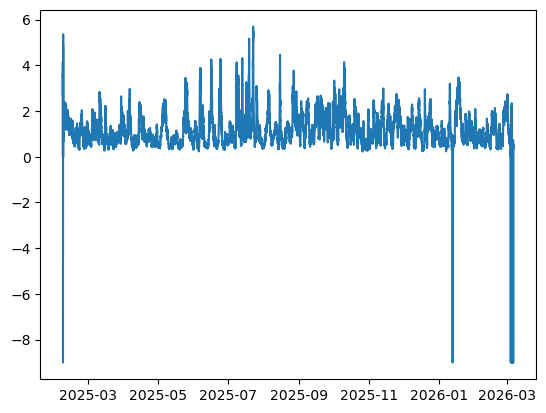

In [6]:
plt.plot(ds.time,ds.Height_Hm0)

In [8]:
import plotly.graph_objects as go

fig = go.Figure()
fig.add_trace(
    go.Scatter(
        x=ds.time.values,
        y=ds.Height_Hm0.values,
        mode='lines',
        name='Height_Hm0'
    )
)
fig.update_layout(
    title='Height_Hm0',
    xaxis_title='Time',
    yaxis_title='Height_Hm0'
)
fig.show()


In [30]:
output_folder = "/datasets/work/oa-srsalt/work/preqa/SWOT/cal_val/jason_calval/all_mooring_data/proc_2/rec_202603/BASJAS_PTSUVW_202603/SIG500_103017"
output_file = os.path.join(output_folder, "BASJAS_W_202603.nc")
output_filep = os.path.join(output_folder, "BASJAS_W_202603_cutandfixfillvalues.nc")


need to implement a test, if hm0 < 0 then all params to default value.

In [27]:
# mask where Height_Hm0 is negative
mask = dsc.Height_Hm0 < 0
mask
fig = go.Figure()
fig.add_trace(
    go.Scatter(
        x=dsc.time.values,
        y=mask.values.astype(int),
        mode='lines',
        name='Hm0_negative_mask'
    )
)
fig.update_layout(
    title='Height_Hm0 negative mask',
    xaxis_title='Time',
    yaxis_title='Mask (1=negative)',
    yaxis=dict(tickmode='array', tickvals=[0,1])
)
fig.show()

In [32]:
# mask where Height_Hm0 is negative
mask = dsc.Height_Hm0 < 0
mask
# for each variable, replace those time steps with its fill value
for var in dsc.data_vars:
    if "missing_value" in dsc[var].attrs:
        fill_value = dsc[var].attrs["missing_value"]
    elif "_FillValue" in dsc[var].attrs:
        fill_value = dsc[var].attrs["_FillValue"]
    else:
        continue

    dsc[var] = dsc[var].where(~mask, fill_value)

# remove fill-value-like attributes from coordinate variables
for coord_name in dsc.coords:
    for attr_name in ("_FillValue", "missing_value", "fill_value"):
        dsc[coord_name].attrs.pop(attr_name, None)
        dsc.[coord_name].attrs.pop(attr_name, None)


In [62]:
dsc["time"].attrs.pop("_FillValue", None)
dsc["time"].encoding.pop("_FillValue", None)
print(dsc["time"].encoding)

{'dtype': dtype('float64'), 'zlib': False, 'szip': False, 'zstd': False, 'bzip2': False, 'blosc': False, 'shuffle': False, 'complevel': 0, 'fletcher32': False, 'contiguous': True, 'chunksizes': None, 'source': '/datasets/work/oa-srsalt/work/preqa/SWOT/cal_val/jason_calval/all_mooring_data/proc_2/rec_202603/BASJAS_PTSUVW_202603/SIG500_103017/BASJAS_W_202603.nc', 'original_shape': (28288,), 'units': 'seconds since 1970-01-01T00:00:00+00:00', 'calendar': 'gregorian'}


In [ ]:
dsc["time"].assign_attrs(_FillValue=None, units="Celsius", description = "Time of measurement"
)

In [57]:
dsc["time"].drop_attrs("_FillValue")

TypeError: DataArray.drop_attrs() takes 1 positional argument but 2 were given

In [63]:
dsc.to_netcdf(output_filep)


In [12]:
ds.to_netcdf(output_file)

In [15]:
folder="/datasets/work/oa-srsalt/work/preqa/SWOT/cal_val/jason_calval/all_mooring_data/proc_2/rec_202603/BASJAS_PTSUVW_202603/SIG500_103017"
os.chdir(folder)
file_in = "BASJAS_W_202603.nc"
# file_in = "merged_burst_waves__SWOTMID_JAS_2023_FSP.nc"
ds = xr.open_dataset(file_in)

In [16]:
# start_plot = datetime.datetime(2023, 2, 14, 00)
start_plot = datetime.datetime(2025, 2, 7, 3,40,0)
# end_plot = datetime.datetime(2023, 8, 6, 00)
end_plot = datetime.datetime(2026, 3, 4, 2, 20,0)
dsc=ds.sel(time=slice(start_plot, end_plot))

In [18]:
dsc

<xarray.Dataset> Size: 4GB
Dimensions:                               (time: 28076,
                                           EnergySpectra_Frequency: 98,
                                           FrequencyDiagram_Frequency: 98,
                                           FourierCoefficients_Frequency: 98,
                                           WaveSpectra_Frequency: 98,
                                           DirectionalSpectra_Frequency: 98,
                                           ...
                                           ASTSpectra_Direction: 90,
                                           ASTSpectra_Frequency: 98,
                                           PressureSpectra_Direction: 90,
                                           PressureSpectra_Frequency: 98,
                                           VelocitySpectra_Direction: 90,
                                           VelocitySpectra_Frequency: 98)
Coordinates: (12/14)
  * time                                  (time) datetime64[ns] 225kB 2025-02...
  * EnergySpectra_Frequency               (EnergySpectra_Frequency) float64 784B ...
  * FrequencyDiagram_Frequency            (FrequencyDiagram_Frequency) float64 784B ...
  * FourierCoefficients_Frequency         (FourierCoefficients_Frequency) float64 784B ...
  * WaveSpectra_Frequency                 (WaveSpectra_Frequency) float64 784B ...
  * DirectionalSpectra_Frequency          (DirectionalSpectra_Frequency) float64 784B ...
    ...                                    ...
  * ASTSpectra_Direction                  (ASTSpectra_Direction) float64 720B ...
  * ASTSpectra_Frequency                  (ASTSpectra_Frequency) float64 784B ...
  * PressureSpectra_Direction             (PressureSpectra_Direction) float64 720B ...
  * PressureSpectra_Frequency             (PressureSpectra_Frequency) float64 784B ...
  * VelocitySpectra_Direction             (VelocitySpectra_Direction) float64 720B ...
  * VelocitySpectra_Frequency             (VelocitySpectra_Frequency) float64 784B ...
Data variables: (12/82)
    Status_Missing_Data                   (time) float32 112kB ...
    Status_No_Pressure                    (time) float32 112kB ...
    Status_Low_Pressure                   (time) float32 112kB ...
    Status_Amplitude                      (time) float32 112kB ...
    Status_White_Noise                    (time) float32 112kB ...
    Status_Unreasonable_Estimate          (time) float32 112kB ...
    ...                                    ...
    Direction                             (DirectionalSpectra_Frequency, time) float32 11MB ...
    DirectionalSpectra_Spread             (DirectionalSpectra_Frequency, time) float32 11MB ...
    FullWaveDirectionalSpectra_Energy     (time, FullWaveDirectionalSpectra_Direction, FullWaveDirectionalSpectra_Frequency) float32 991MB ...
    ASTSpectra_Energy                     (time, ASTSpectra_Direction, ASTSpectra_Frequency) float32 991MB ...
    PressureSpectra_Energy                (time, PressureSpectra_Direction, PressureSpectra_Frequency) float32 991MB ...
    VelocitySpectra_Energy                (time, VelocitySpectra_Direction, VelocitySpectra_Frequency) float32 991MB ...

In [23]:
# plt.figure()
# # plt.plot(ds.time[start_plot:end_plot],ds.Height_Hm-2[start_plot:end_plot])
# plt.plot(dsc.time,dsc.Height_H10)
# # plt.plot(dsc.time,dsc.Height_Hm-2)

# plt.xlim([start_plot, end_plot])

fig = go.Figure()
fig.add_trace(
    go.Scatter(
        x=dsc.time.values,
        y=dsc.Height_Hm0.values,
        mode='lines',
        name='Height_Hm0'
    )
)
fig.update_layout(
    title='Height_Hm0',
    xaxis_title='Time',
    yaxis_title='Height_Hm0'
)
fig.show()

In [ ]:
# indbad=np.where(dsc.Height_H3<0)
# indbad

In [ ]:
# dsc.Height_Hm0[indbad]=np.nan
# plt.figure(figsize=(30,5))
# plt.plot(dsc.time,dsc.Height_Hm0)


In [ ]:
# dsc

In [ ]:
# plt.rcParams.keys()

In [ ]:
# pr_st=5
# pr_en=25
# fr_en=1/pr_st
# fr_st=1/pr_en

# dscp=dsc.sel(WaveSpectra_Frequency=slice(fr_st, fr_en), DirectionalSpectra_Frequency=slice(fr_st, fr_en))
# dscp

In [ ]:
# t_st=np.datetime64('2023-05-30')
# t_en=np.datetime64('2023-06-02')
# tav_st=np.datetime64('2023-05-31')
# tav_en=np.datetime64('2023-06-01')

In [ ]:
# # figure('spectra_with_time')
# plt.rcParams.update({'font.size': 26})
# plt.rcParams.update({'font.weight': 'bold'})
# fig,ax=plt.subplots(3,1, figsize=(30,15), sharex=True)

# hm0_ymax=6.0
# pr_max=20
# ax[0].plot(dscp.time,dscp.Height_Hm0, lw=3)
# ax[0].fill_between([t_st,t_en],[0,0],[hm0_ymax,hm0_ymax],alpha=0.2, color='pink')
# ax[0].set_ylim(0,hm0_ymax)

# img=ax[1].pcolormesh(dscp.time, 1/dscp.WaveSpectra_Frequency, dscp.WaveSpectra_Vel, shading='auto', cmap='jet', vmin=0, vmax=1)
# ax[1].set_ylim(pr_st,pr_max)
# ax[1].fill_between([t_st,t_en],[pr_st,pr_st],[pr_max,pr_max],alpha=0.4, color='pink')
# box=ax[0].get_position()
# ax[0].set_position([box.x0, box.y0, box.width * 0.8, box.height*1])
# cbar=plt.colorbar(img)

# imgaz=ax[2].pcolormesh(dscp.time, 1/dscp.DirectionalSpectra_Frequency, dscp.Direction, shading='auto', cmap='jet', vmin=0, vmax=360)
# cbar=plt.colorbar(imgaz)
# ax[2].set_ylim(pr_st,pr_max)
# ax[2].set_ylabel('period (s)',fontweight='bold')
# ax[1].set_ylabel('period (s)',fontweight='bold')
# ax[1].set_title('spectral amplitude (m2/Hz)',fontweight='bold')
# ax[2].set_title(' azimuth',fontweight='bold')
# ax[0].set_title('SWH (m)',fontweight='bold')
# ax[0].grid()
# ax[1].grid()
# ax[2].grid()

# # Specify the filename and format (jpg)
# plt.savefig('spectra_with_time.jpg', format='jpg')

# # Close the plot (optional)
# # plt.close()

In [ ]:
# fr_en=1/5
# fr_st=1/30

# t_st=np.datetime64('2023-05-30')
# t_en=np.datetime64('2023-06-02')
# tav_st=np.datetime64('2023-05-31')
# tav_en=np.datetime64('2023-06-01')
# dscaz=dsc.sel(time=slice(t_st,t_en),ASTSpectra_Frequency=slice(fr_st, fr_en))
# dscazav=dsc.sel(time=slice(tav_st,tav_en),ASTSpectra_Frequency=slice(fr_st, fr_en))
# period_azimuth_amplitude=dscazav.ASTSpectra_Energy.mean(axis=0)
# # period_azimuth_amplitude=period_azimuth_amplitude
# len(dscaz.ASTSpectra_Frequency)
# len(dscaz.ASTSpectra_Frequency)

In [ ]:
# plt.rcParams.update({'font.size': 26})
# plt.rcParams.update({'font.weight': 'bold'})

# # figure('spectra_dir_with_time')
# # fig,ax=plt.subplots(3,1, figsize=(30,15), sharex=True)
# fig,ax=plt.subplots(3,1, figsize=(30,15))
# fr_en=1/5
# fr_st=1/30

# # graph 1
# hm0_ymax=3.5
# ax[0].plot(dscaz.time,dscaz.Height_Hm0, lw=3)
# box=ax[0].get_position()
# ax[0].set_position([box.x0, box.y0, box.width * 0.8, box.height*1])
# ax[0].set_ylim(0, hm0_ymax)
# ax[0].set_xlim(t_st,t_en)
# ax[0].set_title('SWH (m)',fontweight='bold')
# ax[0].grid()
# # ax[0].add_patch(plt.Rectangle(tav_st,0.5,(tav_en-tav_st),2.5))
# ax[0].fill_between([tav_st,tav_en],[0,0],[hm0_ymax,hm0_ymax],alpha=0.2, color='pink')
# # graph 2 
# # dscp=dsc.sel(DirectionalSpectra_Frequency=slice(fr_st, fr_en))
# img=ax[1].pcolormesh(dscaz.time, 1/dscaz.DirectionalSpectra_Frequency, dscaz.Direction, shading='auto', cmap='jet', vmin=0, vmax=360)
# # box=ax[0].get_position()
# # ax[1].set_position([box.x1, box.y1, box.width * 0.8, box.height*1])
# ax[1].set_xlim(t_st,t_en)
# cbar=plt.colorbar(img)
# ax[1].set_ylim(1/fr_en, 1/fr_st)
# ax[1].set_ylabel('period (s)',fontweight='bold')
# ax[1].set_title('Azimuth',fontweight='bold')
# ax[1].grid()

# # graph 3
# imgaz=ax[2].pcolormesh(1/dscaz.ASTSpectra_Frequency.values, dscaz.ASTSpectra_Direction.values,period_azimuth_amplitude, shading='auto', cmap='jet', norm=LogNorm())
# cbar=plt.colorbar(imgaz)
# ax[2].set_xlim(1/fr_en, 20)
# ax[2].set_xlabel('period (s)',fontweight='bold')
# ax[2].set_ylabel('azimuth (\u00b0)',fontweight='bold')
# ax[2].set_title('spectral amplitude (m2/Hz)',fontweight='bold')
# ax[2].grid()
# # plt.tight_layout()

# plt.savefig('directional_spectra_zoom.jpg', format='jpg')


In [ ]:
# # %matplotlib notebook
# %matplotlib inline

# fig,ax=plt.subplots(2,1, figsize=(30,15))
# fr_en=1/2
# fr_st=1/20
# ax[0].plot(dscp.time,dscp.Height_Hm0)

# dscp=dsc.sel(DirectionalSpectra_Frequency=slice(fr_st, fr_en))
# img=ax[1].pcolormesh(dscp.time, 1/dscp.DirectionalSpectra_Frequency, dscp.Direction, shading='auto', cmap='jet', vmin=0, vmax=360)
# ax[0].set_xlim(np.datetime64('2023-06-16'),np.datetime64('2023-06-18'))

# cbar=plt.colorbar(img)
